# TikTok Claims Classification: Part 2 - Machine learning models

The TikTok data team seeks to develop a machine learning model to assist in the classification of videos as either claims or opinions. The purpose of this model is to mitigate misinformation in videos on the TikTok platform.by predicting whether a TikTok video presents a "claim" or presents an "opinion".

#### **Modeling workflow and model selection process**

Previous investigation into the available data revealed that video engagement levels were highly indicative of claim status, and that there are ~20,000 videos in the sample. This is sufficient to conduct a rigorous model validation workflow, broken into the following steps:

1. Split the data into train/validation/test sets (60/20/20)

2. Fit models and tune hyperparameters on the training set

3. Perform final model selection on the validation set

4. Assess the champion model's performance on the test set





## **Import packages**

In [82]:
# Import packages for data manipulation
import pandas as pd
import numpy as np
import pickle
from sklearn.feature_extraction.text import CountVectorizer

# Import packages for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import packages for data modeling
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import precision_score, accuracy_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from xgboost import plot_importance

def classification_scores(y_val, y_pred):
    scores = [recall_score, precision_score, accuracy_score, f1_score]
    result = {func.__name__:func(y_val,y_pred) for func in scores}
    return result

Load the data from the provided csv file previously cleaned into a dataframe.

In [74]:
data = pd.read_csv("./data/tiktok_dataset_cleaned.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19084 entries, 0 to 19083
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19084 non-null  int64  
 1   claim_status              19084 non-null  object 
 2   video_id                  19084 non-null  int64  
 3   video_duration_sec        19084 non-null  int64  
 4   video_transcription_text  19084 non-null  object 
 5   verified_status           19084 non-null  object 
 6   author_ban_status         19084 non-null  object 
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
dtypes: float64(5), int64(3), object(4)
memory usage: 1.7+ MB


### About outliers
Tree-based models are robust to outliers, so there is no need to handle or drop any values based on where they fall in their distribution.

### Check class balance

In [75]:
# Check class balance
data["claim_status"].value_counts(normalize=True)

claim_status
claim      0.503458
opinion    0.496542
Name: proportion, dtype: float64

50.3% of the dataset represents claims and 49.7% represents opinions, so the outcome variable is balanced.

## **Feature engineering**

The feature `video_transcription_text` is text-based. It is not a categorical variable, since it does not have a fixed number of possible values. A new `text_length` (character count) column is added as a feature to train the model.

In [76]:
# Create `text_length` column
data['text_length'] = data['video_transcription_text'].str.len()

#Calculate the average `text_length` for claims and opinions.
data[['claim_status', 'text_length']].groupby('claim_status').mean()

,text_length
claim_status,
claim,95.376978
opinion,82.722562


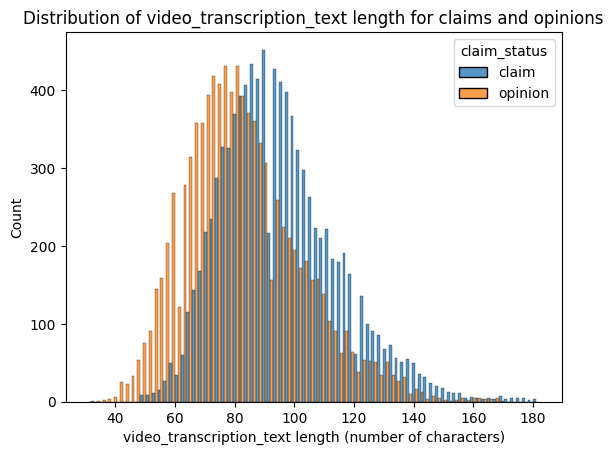

In [77]:
# Plot text length distribution by claim_status
ax = sns.histplot(data=data, x='text_length', multiple="dodge",hue= 'claim_status')
plt.xlabel("video_transcription_text length (number of characters)")
plt.ylabel("Count")
plt.title("Distribution of video_transcription_text length for claims and opinions")
plt.show()

Character count distributions for both claims and opinions are approximately normal with a slight right skew. Claim videos tend to have 13 characters more in average.

**Feature selection and transformation**

Columns like `#` and `video_id` need to be dropped from the dataframe as they are not good predictors. The column `video_transcription_text` would need to be dropped out as well, but it will be removed later after extracting numerical features using a Bag-of-words algorithm.

Columns `verified_status` and `author_ban_status` are categorical features that need to be encoded. As well as `claim_status` column, as it is the target variable.

In [78]:
X = data.copy()
# Drop unnecessary columns
X = X.drop(['#', 'video_id'], axis=1)

# Encode target variable
X['claim_status'] = X['claim_status'].map({'opinion': 0, 'claim': 1})
# Dummy encode remaining categorical values
X = pd.get_dummies(X,
                   columns=['verified_status', 'author_ban_status'],
                   drop_first=True)

## **Split the data**

The target variable is `claim_status`, where 0 represents an opinion and 1 reresents a claim. The rest of the columns in the dataset are features.

In [79]:
# Isolate target variable
y = X['claim_status']
# Isolate features
X = X.drop(['claim_status'], axis=1)

## **Create train/validate/test sets**

1. **Split the data into train/validation/test sets (60/20/20)**

2. Fit models and tune hyperparameters on the training set

3. Perform final model selection on the validation set

4. Assess the champion model's performance on the test set


Split data into training and testing sets, 80/20.

In [80]:
# Split the data into training and testing sets
X_tr, X_test, y_tr, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Split the training set into training and validation sets, 75/25, to result in a final ratio of 60/20/20 for train/validate/test sets.

In [81]:
# Split the training data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_tr, y_tr, test_size=0.25, random_state=42)

### Tokenize text column
The feature `video_transcription_text` is not categorical. Additionally to the text length, an algorithm to extract numerical features is used. Starting with the training data.

In [85]:
count_vec = CountVectorizer(ngram_range=(2, 3),
                            max_features=15,
                            stop_words='english')

# Extract numerical features from `video_transcription_text` in the training set
count_data = count_vec.fit_transform(X_train['video_transcription_text']).toarray()

# Place the numerical representation of `video_transcription_text` from training set into a dataframe
count_df = pd.DataFrame(data=count_data, columns=count_vec.get_feature_names_out())

# Concatenate `X_train` and `count_df` to form the final dataframe for training data (`X_train_final`)
X_train_final = pd.concat([X_train.drop(columns=['video_transcription_text']).reset_index(drop=True), count_df], axis=1)
X_train_final.head()

,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length,verified_status_verified,author_ban_status_banned,author_ban_status_under review,...,friend read,internet forum,internet forum claim,learned media,media claim,news claim,point view,read media,social media,willing wager
0,55,254459.0,66996.0,2673.0,220.0,95.0,97,False,False,True,...,0,0,0,1,0,0,0,0,0,0
1,40,433056.0,85389.0,13301.0,1766.0,1.0,110,False,False,True,...,0,0,0,0,0,0,0,1,0,0
2,29,997358.0,83574.0,17310.0,951.0,530.0,155,False,True,False,...,0,1,1,0,0,0,0,0,0,0
3,15,122973.0,53791.0,14407.0,257.0,8.0,89,False,True,False,...,0,0,0,0,0,0,0,0,0,0
4,17,948.0,309.0,61.0,8.0,2.0,77,True,False,False,...,0,0,0,0,0,0,0,0,0,0


The same is done for the validation and test data.

In [86]:
# Extract numerical features from `video_transcription_text` in the testing set
validation_count_data = count_vec.transform(X_val['video_transcription_text']).toarray()

# Place the numerical representation of `video_transcription_text` from validation set into a dataframe
validation_count_df = pd.DataFrame(data=validation_count_data, columns=count_vec.get_feature_names_out())

# Concatenate `X_val` and `validation_count_df` to form the final dataframe for training data (`X_val_final`)
X_val_final = pd.concat([X_val.drop(columns=['video_transcription_text']).reset_index(drop=True), validation_count_df], axis=1)

X_val_final.head()

,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length,verified_status_verified,author_ban_status_banned,author_ban_status_under review,...,friend read,internet forum,internet forum claim,learned media,media claim,news claim,point view,read media,social media,willing wager
0,34,761969.0,502599.0,94675.0,3242.0,1763.0,98,False,False,False,...,0,0,0,0,1,0,0,0,1,0
1,54,4168.0,965.0,106.0,9.0,2.0,95,False,False,False,...,0,0,0,0,0,0,0,0,0,0
2,43,8347.0,1684.0,134.0,39.0,7.0,84,False,False,False,...,0,0,0,0,0,0,0,0,0,0
3,6,6902.0,2861.0,20.0,27.0,1.0,74,False,False,False,...,0,0,0,0,0,0,0,0,0,0
4,20,37.0,8.0,1.0,0.0,0.0,96,False,False,False,...,0,0,0,0,0,0,0,0,0,1


In [87]:
# Extract numerical features from `video_transcription_text` in the testing set
test_count_data = count_vec.transform(X_test['video_transcription_text']).toarray()

# Place the numerical representation of `video_transcription_text` from test set into a dataframe
test_count_df = pd.DataFrame(data=test_count_data, columns=count_vec.get_feature_names_out())

# Concatenate `X_val` and `validation_count_df` to form the final dataframe for training data (`X_val_final`)
X_test_final = pd.concat([X_test.drop(columns=['video_transcription_text']).reset_index(drop=True), test_count_df], axis=1)
X_test_final.head()

,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length,verified_status_verified,author_ban_status_banned,author_ban_status_under review,...,friend read,internet forum,internet forum claim,learned media,media claim,news claim,point view,read media,social media,willing wager
0,22,6517.0,337.0,120.0,5.0,0.0,73,False,False,False,...,0,0,0,0,0,0,0,0,0,0
1,39,758131.0,41367.0,11288.0,774.0,143.0,83,False,False,False,...,0,0,0,0,0,0,0,0,1,0
2,17,613559.0,368043.0,113662.0,7130.0,4288.0,76,False,False,False,...,0,0,0,0,0,0,0,0,0,0
3,9,363966.0,196481.0,1246.0,1593.0,657.0,114,False,False,False,...,0,0,0,0,0,0,0,0,0,0
4,5,582955.0,86748.0,7182.0,865.0,21.0,98,False,False,True,...,0,0,0,0,0,0,0,0,0,0


Confirm that the dimensions of the training, validation, and testing sets are in alignment.

In [89]:
# Get shape of each training, validation, and testing set
for i in [X_train_final, X_val_final, X_test_final, y_train, y_val, y_test]: print(i.shape)   

(11450, 25)
(3817, 25)
(3817, 25)
(11450,)
(3817,)
(3817,)


The number of features aligns between the datasets, as well as the numer of rows.

## **Build models**
1. Split the data into train/validation/test sets (60/20/20)

2. **Fit models and tune hyperparameters on the training set**

3. Perform final model selection on the validation set

4. Assess the champion model's performance on the test set

**Select an evaluation metric**

There are two possibilities for bad predictions:

  - **False positives:** When the model predicts a video is a claim when in fact it is an opinion
  - **False negatives:** When the model predicts a video is an opinion when in fact it is a claim

It is better to ban a video classified as claim that is in fact an opinion (False Positive), than letting a video unbanned that is a claim classified as an opinion (Flase Negative). It's very important to identify videos that break the terms of service, even if that means some opinion videos are misclassified as claims.

Because it's more important to minimize false negatives, the model evaluation metric will be **recall**.

### **Build a random forest model**


Use cross-validation to tune the hyperparameters and select the model that performs best on recall.

In [97]:
# Instantiate the random forest classifier
rf = RandomForestClassifier(random_state=42)

# Create a dictionary of hyperparameters to tune
cv_params = {'n_estimators': [100,200],
             'max_depth': [5, 10, None],
             'max_features': ['sqrt', 'log2'],
             'min_samples_leaf': [10,50,100],
             }

# Define a list of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1']

# Instantiate the GridSearchCV object
rf_cv = GridSearchCV(rf, cv_params, scoring=scoring, cv=5, refit='recall')

Fit a random forest model to the training set.

**Note** this cell might take several minutes to run. If the model has been already trained and saved, it can be loaded directly to save processing time.

In [98]:
%%time
#rf_cv.fit(X_train_final, y_train)
#pickle.dump(rf_cv, open('./models/rf_cv_vec.sav', 'wb'))

# uncomment this if the model has been trained and saved
rf_cv = pickle.load(open('./models/rf_cv_vec.sav', 'rb'))

CPU times: total: 15.6 ms
Wall time: 4.29 ms


In [94]:
# Examine best parameters
rf_cv.best_params_

{'max_depth': 10,
 'max_features': 'sqrt',
 'min_samples_leaf': 10,
 'n_estimators': 100}

In [95]:
# Examine best recall score

rf_cv.best_score_

np.float64(0.9910316563029961)

In [96]:
# Examine best average prcision score
rf_cv.cv_results_['mean_test_precision'][rf_cv.best_index_]

np.float64(0.9991319444444444)

The model is performing extremely well with a recall score of 0.991 and a precision score of 0.9991.

### **Build an XGBoost model**

The same procedure as for the forest random is done for this model.

In [99]:
# Instantiate the XGBoost classifier
xgb = XGBClassifier(objective='binary:logistic', random_state=42)

# Create a dictionary of hyperparameters to tune
cv_params = {'max_depth': [4,8,12],
             'min_child_weight': [3, 5],
             'learning_rate': [0.01, 0.1],
             'n_estimators': [200, 300, 500],
             'colsample_bytree':[0.6]
             }

# Define a list of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1']

# Instantiate the GridSearchCV object
xgb_cv = GridSearchCV(xgb, cv_params, scoring=scoring, cv=5, refit='recall')

**Note** this cell might take several minutes to run. If the model has been already trained and saved, it can be loaded directly to save processing time.

In [100]:
%%time
#xgb_cv.fit(X_train_final, y_train)
#pickle.dump(xgb_cv, open('./models/xgb_cv_vec.sav', 'wb'))

# uncomment this if the model has been trained and saved
xgb_cv = pickle.load(open('./models/xgb_cv_vec.sav', 'rb'))

CPU times: total: 15.6 ms
Wall time: 36.3 ms


In [101]:
xgb_cv.best_params_

{'colsample_bytree': 0.6,
 'learning_rate': 0.1,
 'max_depth': 8,
 'min_child_weight': 3,
 'n_estimators': 500}

In [102]:
xgb_cv.best_score_

np.float64(0.9901694385766564)

In [103]:
# Examine best average prcision score
xgb_cv.cv_results_['mean_test_precision'][xgb_cv.best_index_]


np.float64(0.9986104944020179)

This model also performs very well. It is still performing a bit lower than the random forest model. 

Before determing the champion model, the model need to be validated.

## **Evaluate models**
1. Split the data into train/validation/test sets (60/20/20)

2. Fit models and tune hyperparameters on the training set

3. **Perform final model selection on the validation set**

4. Assess the champion model's performance on the test set


### **Random forest**

In [104]:
# Use the random forest "best estimator" model to get predictions on the validation set
y_pred = rf_cv.best_estimator_.predict(X_val_final)

Create a confusion matrix to visualize the results of the classification model.

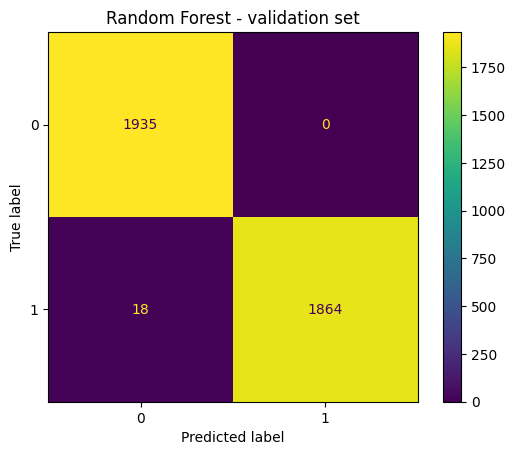

In [105]:
# Compute values for confusion matrix
rf_cm = confusion_matrix(y_val, y_pred)

# Create display of confusion matrix
rf_ax = ConfusionMatrixDisplay(confusion_matrix= rf_cm, display_labels=None)

# Plot confusion matrix
rf_ax.plot()
plt.title('Random Forest - validation set');
plt.show()

Based on the confusion matrix, the forest tree model is displaying 18 false positives (opinions classified as claims), and 0 false negatives(claims classified as opinions). 

In [106]:
classification_scores(y_val, y_pred)

{'recall_score': 0.9904357066950054,
 'precision_score': 1.0,
 'accuracy_score': 0.9952842546502488,
 'f1_score': 0.9951948745328351}

### **XGBoost**

Now, evaluate the XGBoost model on the validation set.

In [107]:
# Use the best estimator to predict on the validation data
y_pred = xgb_cv.best_estimator_.predict(X_val_final)

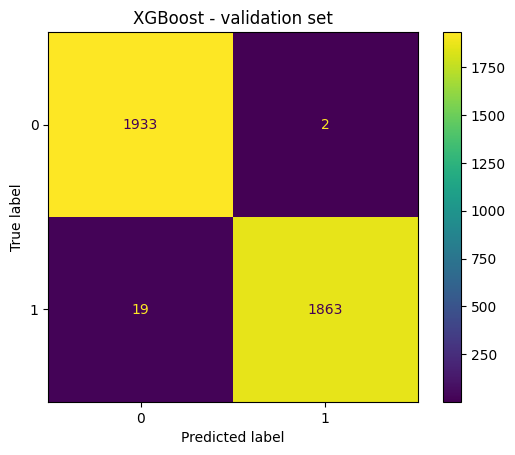

In [110]:
# Compute values for confusion matrix
xgb_cm = confusion_matrix(y_val, y_pred)

# Create display of confusion matrix
xgb_ax = ConfusionMatrixDisplay(confusion_matrix=xgb_cm, display_labels=None)

# Plot confusion matrix
xgb_ax.plot()
plt.title('XGBoost - validation set');
plt.show()


In [111]:
classification_scores(y_val, y_pred)

{'recall_score': 0.98990435706695,
 'precision_score': 0.9989276139410188,
 'accuracy_score': 0.994498297091957,
 'f1_score': 0.9943955164131305}

The XGBoost model also performed nearly perfect.

This comparison table for both models:

|Metric|XGBoost|Random Forest|
|---|---|---|
|Recall|0.9899|0.9904|
|Precision|0.9989|0.9991|
|Accuracy|0.9945|0.9953|
|False Positives|2|0|
|False Negative|19|18|

Even tough both models are performing extremely well, the Random forest model has overall better scores and missed less positive cases than the XGBoost model (better Recall). Additionally, The XGBoost model missed 2 negative cases, while the random forest didn't missed any, making it less precise. 

**Champion Model: Random Forest**

## **Use champion model to predict on test data**

1. Split the data into train/validation/test sets (60/20/20)

2. Fit models and tune hyperparameters on the training set

3. Perform final model selection on the validation set

4. **Assess the champion model's performance on the test set**

Now, the Random Forest model as the champion is used to predict on the test data.

In [123]:
# Use champion model to predict on test data
y_pred = rf_cv.best_estimator_.predict(X_test_final)

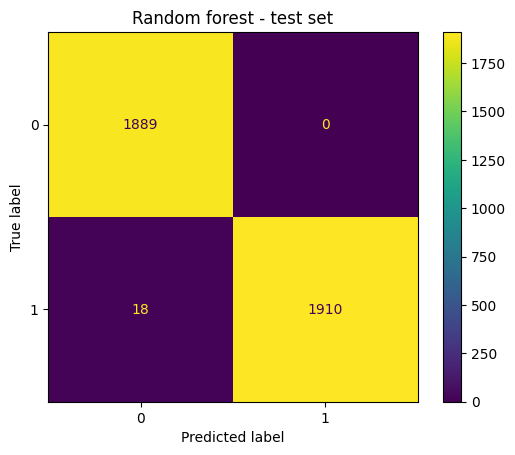

In [124]:
# Compute values for confusion matrix
rf_cm = confusion_matrix(y_test, y_pred)

# Create display of confusion matrix
rf_ax = ConfusionMatrixDisplay(confusion_matrix=rf_cm, display_labels=None)

# Plot confusion matrix
rf_ax.plot()

# Display plot
plt.title('Random forest - test set');
plt.show()

#### **Feature importances of champion model**



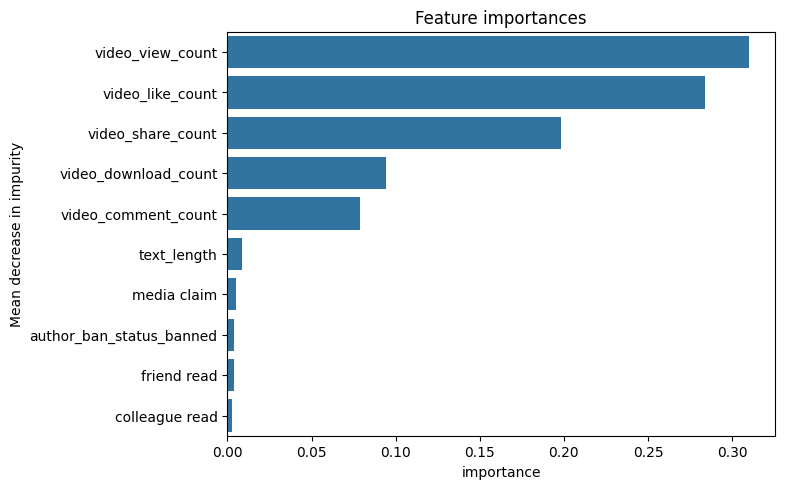

In [125]:
fig, ax = plt.subplots()
ax.set_title('Feature importances')
ax.set_ylabel('Mean decrease in impurity')
fig.tight_layout()

df_rf = pd.DataFrame(rf_cv.best_estimator_.feature_importances_, index=X_train_final.columns, columns=['importance'])
df_rf = df_rf.sort_values('importance', ascending=False)
df_h = df_rf.head(10)
ax = sns.barplot(x=df_h.importance,y= df_h.index)

The most predictive features are all related to engagement levels generated by the video. This is somehow expected as previously found insights in the EDA points to this conclusion.

## **Conclusion**

1. The champion model, the random forest performs very well at detecting if a submission is a claim or an opinion. the metrics, specially the recall, indicate that the model is excellent at minimising the False Negatives (claims as opinions).
2. The model takes the features with more predicting power (views, likes, shares, and downloads) and classifies them in order to detect a pattern of a claim or opinion.
3. Features extracted from the transcription text are not strong predictorscompared to the engagement levels.
